# EXPLORATION ANALYSIS 
Equipo de Análisis de Perfil y Desempeño

In [1]:
# datos y cálculo
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# visualización
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker
import seaborn as sns
import plotly
import plotly.graph_objects as go
import plotly.express as px

# grafo / redes
import networkx as nx
import warnings

# base de datos
import mysql.connector
from mysql.connector import Error

In [2]:
warnings.filterwarnings('ignore', message=".*pandas only supports SQLAlchemy connectable.*")

config = {
    'host': '212.227.90.6',
    'user': 'Equipo24',
    'password': 'E1q2u3i4p5o24',
    'database': 'Equip_24'
}

conn = mysql.connector.connect(**config)
cursor = conn.cursor()

cursor.execute("SELECT database();")
db_actual = cursor.fetchone()[0]
print(f"--- Conectado a la base de datos: {db_actual} ---")

cursor.execute("SHOW TABLES;")
tablas = cursor.fetchall()

dataframes = {}

for (tabla,) in tablas:
    print(f"- {tabla}")
    dataframes[tabla] = pd.read_sql(
        f"SELECT * FROM {tabla}", conn
    )

RRHH = dataframes['RRHH']


--- Conectado a la base de datos: Equip_24 ---
- RRHH


In [3]:
RRHH.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,740.0,18.017568,11.021247,1.0,9.0,18.0,28.0,36.0
Reason_absence,740.0,19.216216,8.433406,0.0,13.0,23.0,26.0,28.0
Month_absence,740.0,6.324324,3.436287,0.0,3.0,6.0,9.0,12.0
Day_week,740.0,3.914865,1.421675,2.0,3.0,4.0,5.0,6.0
Seasons,740.0,2.544595,1.111831,1.0,2.0,3.0,4.0,4.0
Transportation_expense,740.0,221.329730,66.952223,118.0,179.0,225.0,260.0,388.0
Distance_Residence_Work,740.0,29.631081,14.836788,5.0,16.0,26.0,50.0,52.0
Service_time,740.0,12.554054,4.384873,1.0,9.0,13.0,16.0,29.0
Age,740.0,36.450000,6.478772,27.0,31.0,37.0,40.0,58.0
Hit_target,740.0,94.587838,3.779313,81.0,93.0,95.0,97.0,100.0




* **Análisis de Tendencia Central:** El promedio de ausencia es de **6.9 horas**, pero la mediana (percentil 50%) es de solo **3 horas**.
* **Sesgo de Datos:** Esta diferencia indica una distribución asimétrica; un grupo reducido de empleados registra ausencias prolongadas (hasta un máximo de **120 horas**), lo que eleva artificialmente el promedio general.
* **Volatilidad:** Con **740 registros** y una desviación estándar de **13.3**, el fenómeno es altamente variable, lo que dificulta la planificación operativa a corto plazo.

---

### Perfil Demográfico y de Salud

| Variable | Valor Promedio / Rango | Interpretación Profesional |
| --- | --- | --- |
| **Edad (Age)** | **36.4 años** | Fuerza laboral joven-adulta (rango 27-58) en su etapa de máxima productividad. |
| **Antigüedad (Service time)** | **12.5 años** | Consolidación del capital intelectual; los empleados poseen un alto dominio de sus procesos. |
| **Salud (BMI)** | **26.6 (Promedio)** | El colaborador promedio se encuentra en rango de **sobrepeso**, factor de riesgo para futuras bajas médicas. |

---

### Factores Logísticos y Operativos

* **Radio de Movilidad (Distancia):** La distancia promedio es de **29.6 km** (máximo de **52 km**). La logística de transporte es un factor crítico que impacta directamente en la puntualidad y el agotamiento.
* **Eficiencia Operativa (Hit Target):** A pesar de las incidencias, el equipo mantiene un desempeño del **94.5%**, lo que demuestra una alta capacidad de recuperación y compromiso con los objetivos.
* **Dispersión de Costos:** El gasto de transporte presenta una desviación estándar alta (**66.9**), evidenciando una brecha significativa en los costos de traslado entre diferentes segmentos de empleados.

---

### Distribución Temporal

* **Ciclo Mensual:** La media de **6.3** indica que el volumen de datos analizados tiene una mayor densidad durante el primer semestre del año.
* **Patrón Semanal:** El promedio de **3.9** (cercano al jueves) sugiere que las incidencias de ausencia tienden a concentrarse hacia el cierre de la semana laboral.





In [4]:
RRHH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       740 non-null    int64 
 1   Reason_absence           740 non-null    int64 
 2   Month_absence            740 non-null    int64 
 3   Day_week                 740 non-null    int64 
 4   Seasons                  740 non-null    int64 
 5   Transportation_expense   740 non-null    int64 
 6   Distance_Residence_Work  740 non-null    int64 
 7   Service_time             740 non-null    int64 
 8   Age                      740 non-null    int64 
 9   Work_load_Average_day    740 non-null    object
 10  Hit_target               740 non-null    int64 
 11  Disciplinary_failure     740 non-null    object
 12  Education                740 non-null    object
 13  Son                      740 non-null    object
 14  Social_drinker           740 non-null    o

## Tipos de Datos en Pandas y su Aplicación en el Dataset

| Nombre en Pandas | Tipo de Dato Lógico | Aplicación en tu Dataset |
|------------------|--------------------|---------------------------|
| `category,  object` | Categórico | `Reason_absence`, `Education` y `Seasons` y `IDs`. |
| `float` | Decimal |  `Work_load_Average_day`. |
| `int` | Entero |  `Son`, `Pet`, `Age` y `Service_time`. |
| `bool` | Booleano | `Disciplinary_failure` y `Social_drinker` y `Social_smoker`. |
| `object` | Texto / String |  `string`. |

___________________________________________________________________________________________________________________________________________________



* **Análisis de Tendencia Central:** El promedio de ausencia es de **6.9 horas**, pero la mediana (percentil 50%) es de solo **3 horas**.
* **Sesgo de Datos:** Esta diferencia indica una distribución asimétrica; un grupo reducido de empleados registra ausencias prolongadas (hasta un máximo de **120 horas**), lo que eleva artificialmente el promedio general.
* **Volatilidad:** Con **740 registros** y una desviación estándar de **13.3**, el fenómeno es altamente variable, lo que dificulta la planificación operativa a corto plazo.

---

### Perfil Demográfico y de Salud

| Variable | Valor Promedio / Rango | Interpretación Profesional |
| --- | --- | --- |
| **Edad (Age)** | **36.4 años** | Fuerza laboral joven-adulta (rango 27-58) en su etapa de máxima productividad. |
| **Antigüedad (Service time)** | **12.5 años** | Consolidación del capital intelectual; los empleados poseen un alto dominio de sus procesos. |
| **Salud (BMI)** | **26.6 (Promedio)** | El colaborador promedio se encuentra en rango de **sobrepeso**, factor de riesgo para futuras bajas médicas. |

---

### Factores Logísticos y Operativos

* **Radio de Movilidad (Distancia):** La distancia promedio es de **29.6 km** (máximo de **52 km**). La logística de transporte es un factor crítico que impacta directamente en la puntualidad y el agotamiento.
* **Eficiencia Operativa (Hit Target):** A pesar de las incidencias, el equipo mantiene un desempeño del **94.5%**, lo que demuestra una alta capacidad de recuperación y compromiso con los objetivos.
* **Dispersión de Costos:** El gasto de transporte presenta una desviación estándar alta (**66.9**), evidenciando una brecha significativa en los costos de traslado entre diferentes segmentos de empleados.

---

### Distribución Temporal

* **Ciclo Mensual:** La media de **6.3** indica que el volumen de datos analizados tiene una mayor densidad durante el primer semestre del año.
* **Patrón Semanal:** El promedio de **3.9** (cercano al jueves) sugiere que las incidencias de ausencia tienden a concentrarse hacia el cierre de la semana laboral.





In [5]:
RRHH.sample(5)

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
651,36,28,10,3,4,118,13,18,50,"265,017",...,0,1,1,1,0,0,98,178,31,1
405,3,28,10,4,4,179,51,18,38,"284,853",...,0,1,0,1,0,0,89,170,31,3
527,24,28,7,3,1,246,25,16,41,"230,290",...,0,1,0,1,0,0,67,170,23,2
159,3,6,11,3,4,179,51,18,38,"284,031",...,0,1,0,1,0,0,89,170,31,8
664,1,13,1,3,2,235,11,14,37,"330,061",...,0,3,1,0,0,1,88,172,29,1


### crear nueva tabla con indice + reason 

In [6]:
print(f"Registros duplicados: {RRHH.duplicated().sum()}")

Registros duplicados: 34


C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_11812\820722363.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=RRHH, x='Month_absence', palette='rocket')


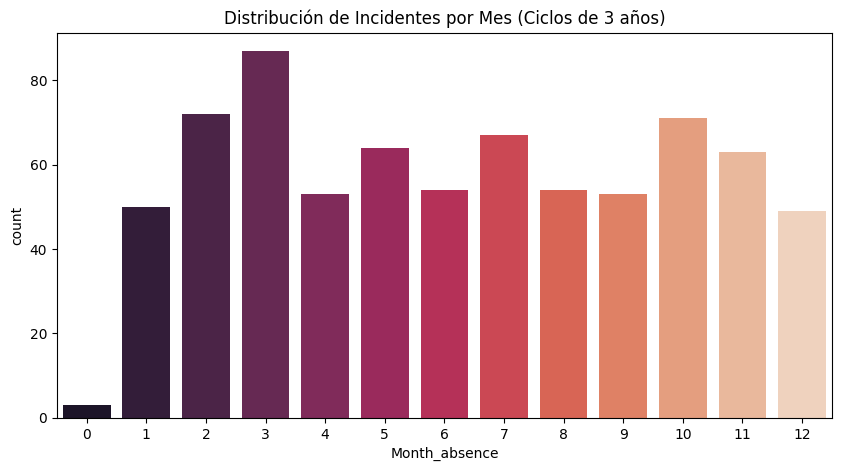

In [7]:

plt.figure(figsize=(10,5))
sns.countplot(data=RRHH, x='Month_absence', palette='rocket')
plt.title('Distribución de Incidentes por Mes (Ciclos de 3 años)')
plt.show()


## Este gráfico muestra la distribución de incidentes por mes. Se observa que la mayoría de las ausencias se concentran en el mes de marzo.

### observación para equipo de limpieza: hay el mes 0

C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_11812\1849998321.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=RRHH, x='Day_week', y='Absenteeism_hours', palette="rocket")


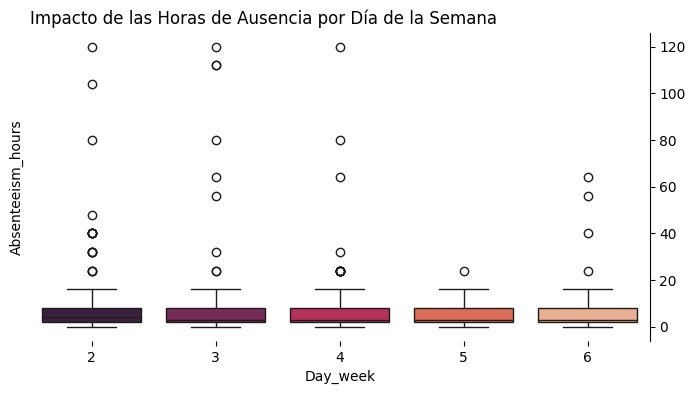

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(data=RRHH, x='Day_week', y='Absenteeism_hours', palette="rocket")
plt.title('Impacto de las Horas de Ausencia por Día de la Semana', loc="left")
sns.despine(right=False, left="False", top='False', bottom="False")
plt.show()

El análisis de este gráfico tipo boxplot revela que, aunque la mayoría de las ausencias en todos los días de la semana son de corta duración (con una mediana cercana a las 3 horas), existe una presencia crítica de valores atípicos (outliers) que distorsionan la operatividad. Se observa que los días 2, 3 y 4 (lunes a miércoles) presentan los casos más extremos, alcanzando picos de hasta 120 horas de ausencia, lo que sugiere incidentes de larga duración o bajas médicas prolongadas que inician a principio de semana. Por el contrario, el día 5 (jueves) muestra la mayor estabilidad con menos valores extremos, mientras que el día 6 (viernes) registra una dispersión moderada, indicando que, aunque hay menos casos de larga duración que el lunes, sigue siendo un punto focal para ausencias que superan la jornada laboral estándar.

# ANÁLISIS DE CASUALIDAD

C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_11812\206477242.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=RRHH, x='Reason_absence', order=order, palette="rocket")


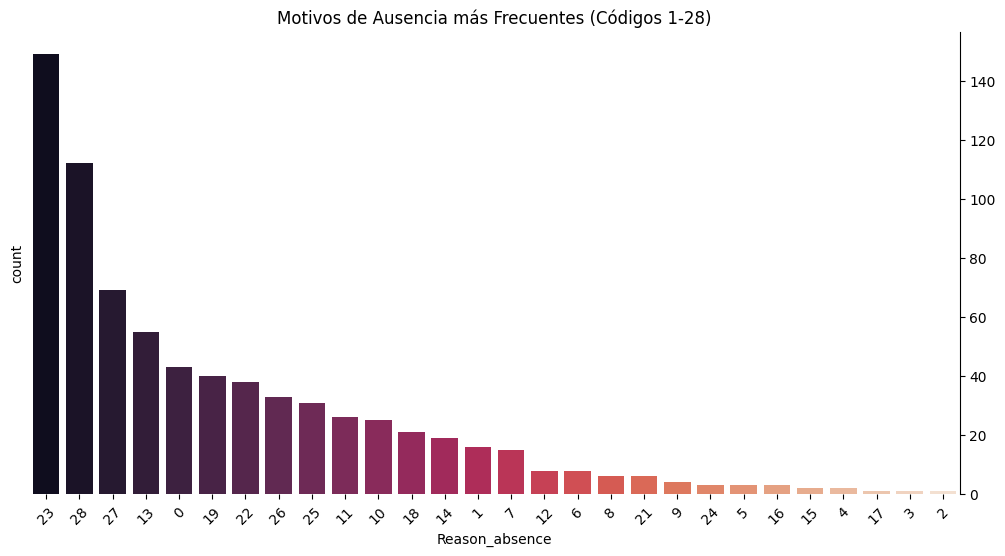

Total de incidentes injustificados: 33


In [9]:

plt.figure(figsize=(12,6))
order = RRHH['Reason_absence'].value_counts().index
sns.countplot(data=RRHH, x='Reason_absence', order=order, palette="rocket")
sns.despine(right=False, left="False", top='False', bottom="False")
plt.title('Motivos de Ausencia más Frecuentes (Códigos 1-28)')
plt.xticks(rotation=45)
plt.show()

unjustified = RRHH[RRHH['Reason_absence'] == 26]
print(f"Total de incidentes injustificados: {len(unjustified)}")

### En este gráfico observamos que la mayoría de las ausencias se deben a visitas médicas (motivo 23), seguidas por consultas odontológicas (motivo 28) y sesiones de fisioterapia (motivo 27). 



# 📊 Clasificación de Enfermedades (CID / ICD)

## 🏥 Categorías con CID

| Código | Categoría                                                                                           |
| ------ | --------------------------------------------------------------------------------------------------- |
| I      | Certain infectious and parasitic diseases                                                           |
| II     | Neoplasms                                                                                           |
| III    | Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism |
| IV     | Endocrine, nutritional and metabolic diseases                                                       |
| V      | Mental and behavioural disorders                                                                    |
| VI     | Diseases of the nervous system                                                                      |
| VII    | Diseases of the eye and adnexa                                                                      |
| VIII   | Diseases of the ear and mastoid process                                                             |
| IX     | Diseases of the circulatory system                                                                  |
| X      | Diseases of the respiratory system                                                                  |
| XI     | Diseases of the digestive system                                                                    |
| XII    | Diseases of the skin and subcutaneous tissue                                                        |
| XIII   | Diseases of the musculoskeletal system and connective tissue                                        |
| XIV    | Diseases of the genitourinary system                                                                |
| XV     | Pregnancy, childbirth and the puerperium                                                            |
| XVI    | Certain conditions originating in the perinatal period                                              |
| XVII   | Congenital malformations, deformations and chromosomal abnormalities                                |
| XVIII  | Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified             |
| XIX    | Injury, poisoning and certain other consequences of external causes                                 |
| XX     | External causes of morbidity and mortality                                                          |
| XXI    | Factors influencing health status and contact with health services                                  |

---

# 📄 Categorías sin CID

Estas categorías **no corresponden a una clasificación CID**, pero son utilizadas para control administrativo en RH:

| Código | Categoría              |
| ------ | ---------------------- |
| 22     | Patient follow-up      |
| 23     | Medical consultation   |
| 24     | Blood donation         |
| 25     | Laboratory examination |
| 26     | Unjustified absence    |
| 27     | Physiotherapy          |
| 28     | Dental consultation    |




### CORRELATION MATRIX

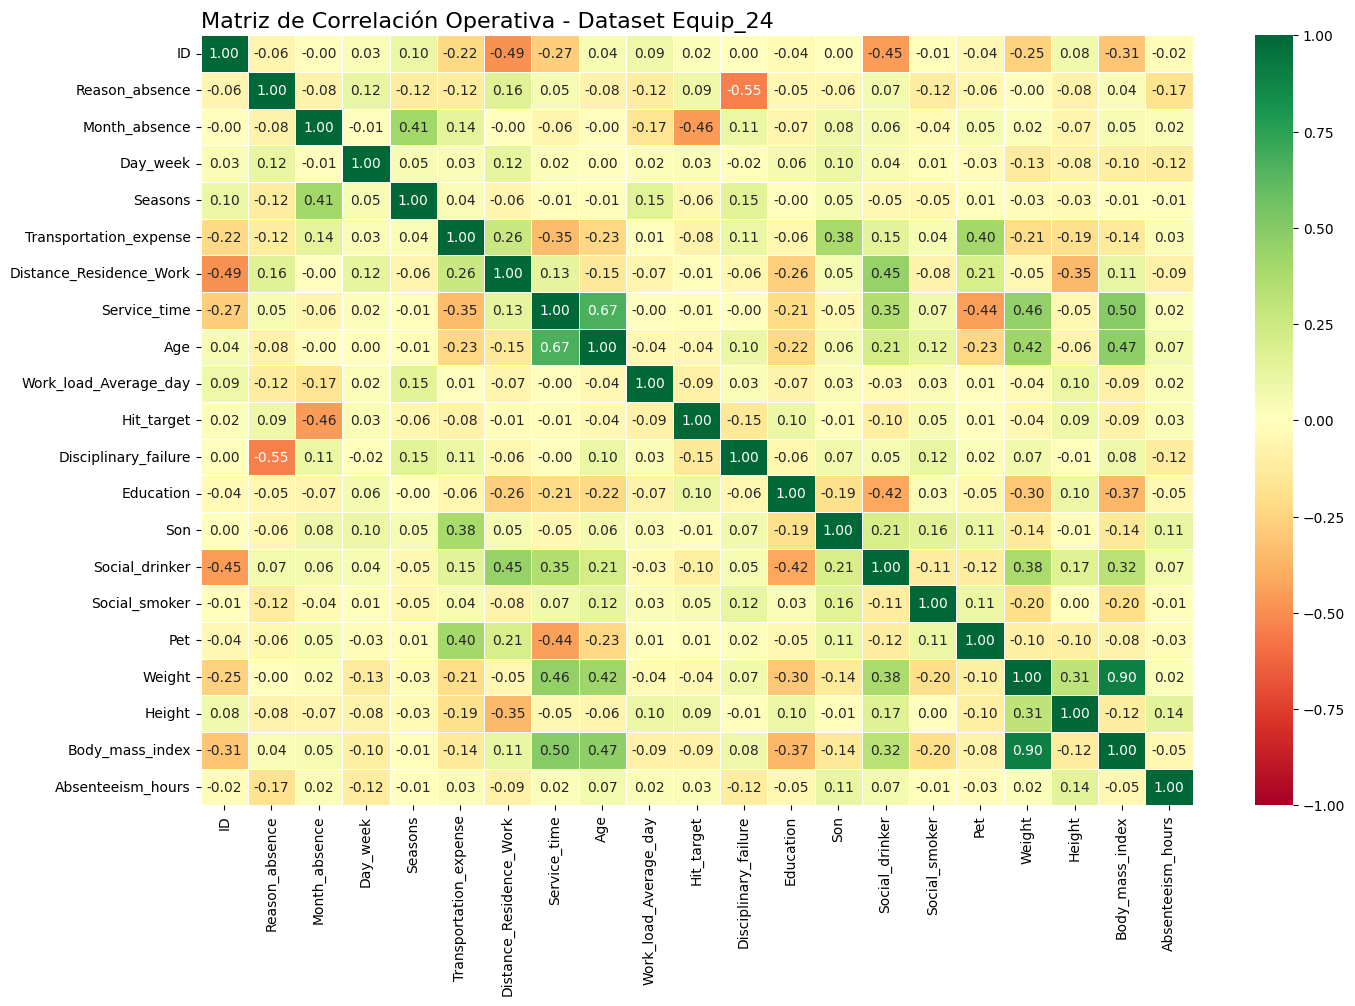

In [10]:
RRHH['Work_load_Average_day'] = RRHH['Work_load_Average_day'].astype(str).str.replace(',', '.').astype(float) # he cambiado para tipo float para sacar el heatmap

cols_to_fix = ['Disciplinary_failure', 'Education', 'Social_drinker', 'Social_smoker', 'Son', 'Pet']
for col in cols_to_fix:
    RRHH[col] = pd.to_numeric(RRHH[col], errors='coerce')


corr = RRHH.select_dtypes(include=[np.number]).corr()


plt.figure(figsize=(16, 10))
sns.heatmap(corr, 
            annot=True,      
            fmt=".2f",      
            cmap='RdYlGn',   
            vmin=-1,        
            vmax=1,          
            center=0,      
            linewidths=.5)   

plt.title('Matriz de Correlación Operativa - Dataset Equip_24', fontsize=16, loc='left')
plt.show()

Existe una correlación superior al 90% entre el Peso (Weight) y el Índice de Masa Corporal (BMI). Dado que el BMI es un indicador calculado directamente a partir del peso y la altura, estas variables presentan una alta redundancia (multicolinealidad). Por lo tanto, resulta estratégicamente viable eliminar las columnas de peso y altura para trabajar exclusivamente con el BMI, simplificando el modelo sin perder información crítica sobre el estado de salud de los empleados.

Se detectó una dependencia crítica entre la antigüedad y la edad (0.67), vinculada a un incremento en el índice de masa corporal (0.47). Esto indica que el capital intelectual de la empresa reside en un segmento demográfico con crecientes riesgos de salud, lo que impacta directamente en la estabilidad operativa a largo plazo.

Tambien es importante destacar la relación de -46% entre "hit target" y "month_abcense", lo que se entiende que el mes que hay menos gente en la planilla el target es bajo.

In [11]:
RRHH.head(5)

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,284.031,...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,239.409,...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,264.604,...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,230.290,...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,222.196,...,0,1,2,0,0,1,65,172,22,112


<Axes: xlabel='Work_load_Average_day', ylabel='Count'>

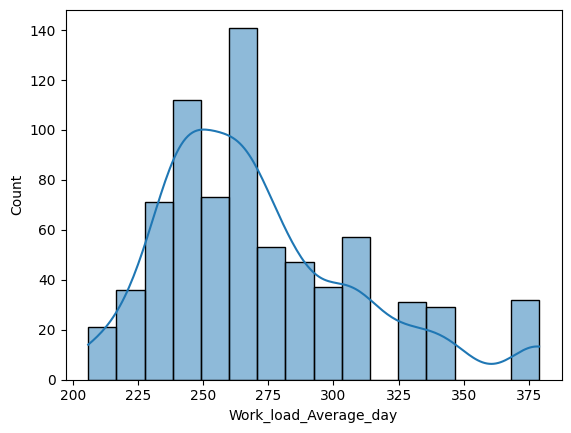

In [12]:
sns.histplot(data=RRHH, x="Work_load_Average_day", kde=True)

<Axes: xlabel='Age', ylabel='Count'>

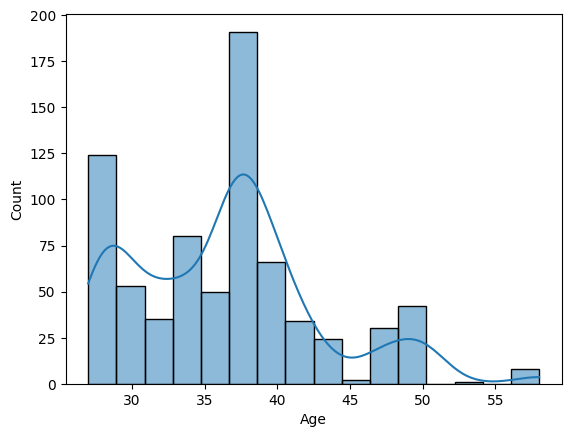

In [13]:
sns.histplot(data=RRHH, x="Age", kde=True)

C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_11812\936550153.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=RRHH, x='Hit_target', y="Month_absence", palette="rocket")


<Axes: xlabel='Hit_target', ylabel='Month_absence'>

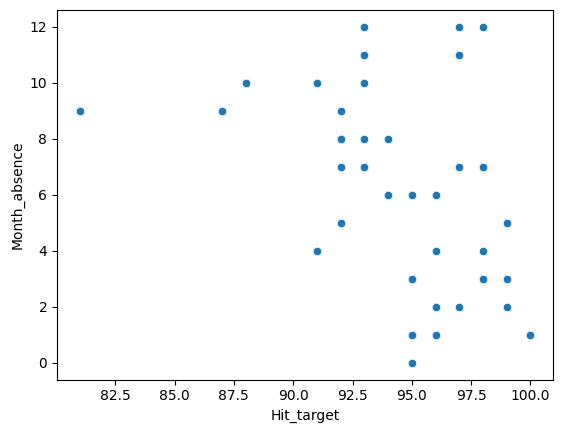

In [14]:
sns.scatterplot(data=RRHH, x='Hit_target', y="Month_absence", palette="rocket")

C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_11812\850509939.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=RRHH, x='Age', y="Service_time", palette="rocket")


<Axes: xlabel='Age', ylabel='Service_time'>

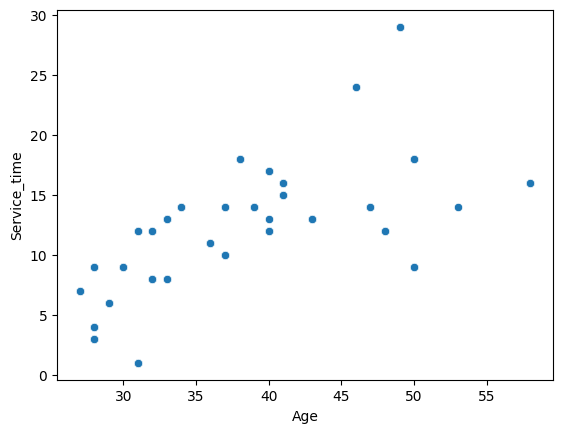

In [15]:
sns.scatterplot(data=RRHH, x='Age', y="Service_time", palette="rocket")

In [16]:
RRHH.columns

Index(['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight',
       'Height', 'Body_mass_index', 'Absenteeism_hours'],
      dtype='object')

C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_11812\1032822318.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=RRHH, x='Body_mass_index', y="Service_time", palette="rocket")


<Axes: xlabel='Body_mass_index', ylabel='Service_time'>

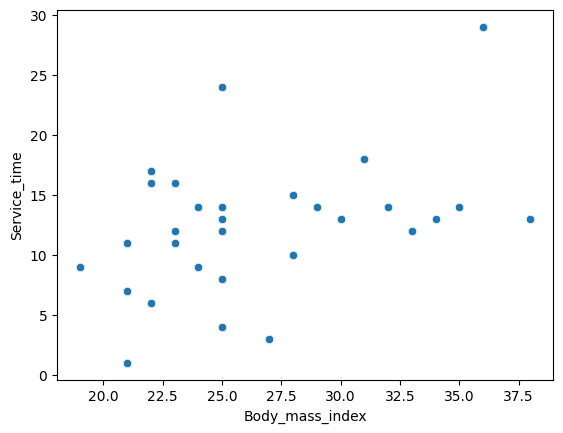

In [17]:
sns.scatterplot(data=RRHH, x='Body_mass_index', y="Service_time", palette="rocket")

C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_11812\2381384304.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=RRHH, x='Absenteeism_hours', palette="rocket")


<Axes: xlabel='Absenteeism_hours'>

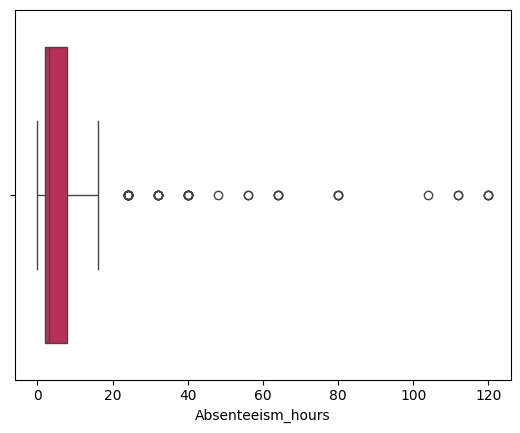

In [18]:
sns.boxplot(data=RRHH, x='Absenteeism_hours', palette="rocket")

C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_11812\1220868314.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=RRHH, x='Absenteeism_hours', palette="rocket", showfliers=False)


<Axes: xlabel='Absenteeism_hours'>

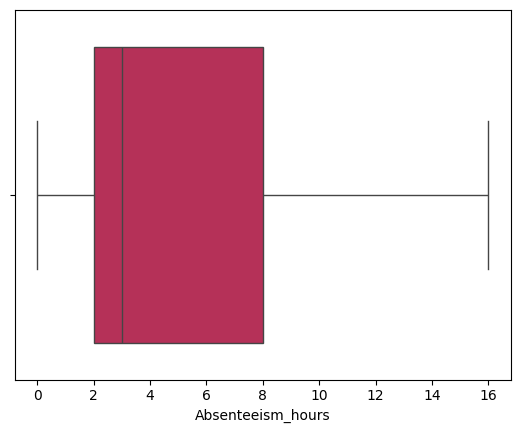

In [19]:
sns.boxplot(data=RRHH, x='Absenteeism_hours', palette="rocket", showfliers=False)

C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_11812\303400625.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=RRHH, x='Body_mass_index', palette="rocket")


<Axes: xlabel='Body_mass_index'>

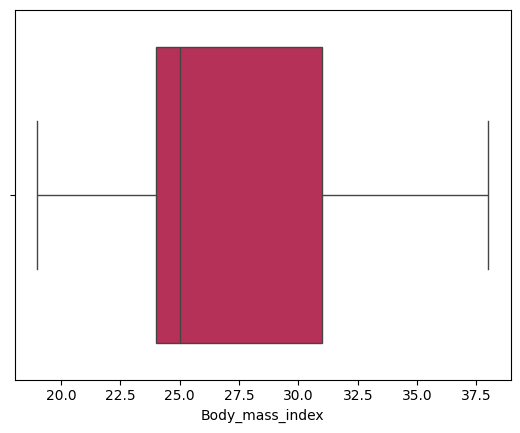

In [20]:
sns.boxplot(data=RRHH, x='Body_mass_index', palette="rocket")

In [21]:
RRHH.sample(5)

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
448,34,25,6,2,1,118,10,10,37,275.089,...,0,1,0,0,0,0,83,172,28,3
574,3,27,3,4,2,179,51,18,38,222.196,...,0,1,0,1,0,0,89,170,31,2
214,13,26,10,3,4,369,17,12,31,284.853,...,0,1,3,1,0,0,70,169,25,8
583,22,23,3,6,2,179,26,9,30,222.196,...,0,3,0,0,0,0,56,171,19,2
474,28,27,1,3,2,225,26,9,28,308.593,...,0,1,1,0,0,2,69,169,24,2


In [22]:
RRHH.columns

Index(['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight',
       'Height', 'Body_mass_index', 'Absenteeism_hours'],
      dtype='object')